In [4]:
import pandas as pd
import numpy as np
from collections import Counter
from datetime import datetime
from tqdm import tqdm
import pyarrow.parquet as pq

In [11]:
# Read Dataset
DATA_PATH = 'dataset/wasabi_raw/proc/'

# the zzzwasabi_songs.csv is over large, please download from https://mega.nz/file/GUhzBagS#dkWiRhRKCzTpbWtWcUvoD3Rrhleq50krvvg6n0SaI-w and put it in the dataset folder
songs = pq.ParquetFile(DATA_PATH + 'song.parquet')

# the wasabi_albums.csv is over large, please download from https://mega.nz/file/ScwnlarS#V59gnQY_oDOFzBplIok7nMnAC2QUq7UpbgmpDjLAWWQ and put it in the dataset folder
albums = pd.read_csv(DATA_PATH + 'album.csv', sep=',') 

# the wasabi_artists.csv is over large, please download from https://mega.nz/file/jUojAQjb#lV6K3U49l0xzw7XzL5zXKQscSI8hntrO_FVp8luH4zE and put it in the dataset folder
artists = pd.read_csv(DATA_PATH + 'artist.csv', sep=',')  

# extract the album publication year from the album dataset and merge that with the songs dataset.
albums_select = albums.rename(columns={'_id': 'id_album', 'publicationDate': 'album_pub_year'})
artists_select = artists.rename(columns={'_id': 'id_artist'})

lyric_data = pd.merge(songs, albums_select, on=['id_album'], how='left') 
lyric_data = pd.merge(lyric_data, artists_select, on=['id_artist'], how='left') 

# remove songs with missing or inconsistent non-numeric year labels.
lyric_data_cleaned = lyric_data.copy()
lyric_data_cleaned['album_pub_year'] = pd.to_datetime(lyric_data_cleaned['album_pub_year'], errors='coerce') # unify the date format to datetime
lyric_data_cleaned = lyric_data_cleaned[pd.toss_numeric(lyric_data_cleaned['album_pub_year'], errors='coerce').notnull()] # convert dates in incorrect formats to null
lyric_data_cleaned = lyric_data_cleaned[pd.notnull(lyric_data_cleaned['album_pub_year'])] # remove all songs with incorrect formats of dates
lyric_data_cleaned['album_pub_year'] = pd.DatetimeIndex(lyric_data_cleaned['album_pub_year']).year # only keep the year part
lyric_data_cleaned = lyric_data_cleaned[(lyric_data_cleaned['album_pub_year'] >= 1960)] # only consider the songs after 1960 to avoid outliers, as songs recored earlier are very sparse.

In [25]:
df = pd.read_csv('dataset/lyrics_annotated_line.csv') 
df['publicationDate']

/var/folders/qf/5crdbb_x01j7jrrtsg93r4dc0000gn/T/ipykernel_94651/215309325.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('dataset/lyrics_annotated_line.csv')


0          1998-06-22
1          1998-06-22
2          1998-06-22
3          1998-06-22
4          1998-06-22
              ...    
1679967           NaN
1679968           NaN
1679969           NaN
1679970    2006-12-01
1679971           NaN
Name: publicationDate, Length: 1679972, dtype: object

In [2]:

# Initialize tqdm with pandas
tqdm.pandas()

# --- Load the dataset with low_memory=False to avoid DtypeWarning ---
df = pd.read_csv('dataset/lyrics_annotated_line.csv', low_memory=False)

# --- Extract year and decade ---
def extract_year(date_str):
    try:
        return pd.to_datetime(date_str, format='%Y-%m-%d').year
    except Exception:
        return np.nan

df['publicationYear'] = df['publicationDate'].progress_apply(extract_year)
df['decade'] = (df['publicationYear'] // 10 * 10).astype('Int64').astype('string') + 's'

# --- Language fallback ---
df['language_final'] = df['language_detect'].fillna(df['language'])

# --- Mean VAD scores ---
# Valence: Average of raw, predicted, and lexicon-based values
vad_cols = ['valence', 'valence_predicted', 'valence_lexicon']
df['valence_mean'] = df[vad_cols].mean(axis=1, skipna=True)

# Arousal: Average of raw, predicted, and lexicon-based values
arousal_cols = ['arousal', 'arousal_predicted', 'arousal_lexicon']
df['arousal_mean'] = df[arousal_cols].mean(axis=1, skipna=True)

# Dominance: Only have 'dominance_lexicon', so use it directly
df['dominance_mean'] = df['dominance_lexicon']

# --- Episode mode ---
def most_common_episode(episodes):
    if isinstance(episodes, str):
        episodes = episodes.strip("[]").replace("'", "").split(", ")
    return Counter(episodes).most_common(1)[0][0] if episodes else np.nan

df['episode_mode'] = df['episode'].progress_apply(most_common_episode)

# --- Line count ---
df['line_count'] = df['lyrics'].astype(str).progress_apply(lambda x: len(x.split('<br>')))

# --- Final subset of columns for trend analysis ---
output_cols = [
    'publicationYear', 'decade', 'language_final', 'isClassic', 'explicitLyrics',
    'valence_mean', 'arousal_mean', 'dominance_mean', 'episode_mode',
    'line_count', 'position'
]
output_df = df[output_cols].rename(columns={'language_final': 'language'})

# --- Export to new CSV ---
output_df.to_csv('dataset/lyrical_emotion_trends.csv', index=False)
print("✅ Saved to 'lyrical_emotion_trends.csv'")

100%|██████████| 1679972/1679972 [00:04<00:00, 419334.35it/s]


✅ Saved to 'lyrical_emotion_trends.csv'


In [30]:
df['publicationYear']

0          1998.0
1          1998.0
2          1998.0
3          1998.0
4          1998.0
            ...  
1679967       NaN
1679968       NaN
1679969       NaN
1679970    2006.0
1679971       NaN
Name: publicationYear, Length: 1679972, dtype: float64

In [23]:
print("Column Headings:", df.columns.tolist())
print("Shape:", df.shape)

Column Headings: ['publicationYear', 'decade', 'language', 'isClassic', 'explicitLyrics', 'valence_mean', 'arousal_mean', 'dominance_mean', 'episode_mode', 'line_count', 'position', 'love_word_count', 'swear_word_count', 'money_word_count', 'sex_word_count', 'neutral_word_count']
Shape: (1679972, 16)


In [36]:
import pandas as pd
import re
from tqdm import tqdm

# Load your datasets
lyrics_df = pd.read_csv('dataset/lyrics_annotated_line.csv', usecols=['lyrics'])

# Define your lexicons
love_words = {'adore', 'affection', 'amour', 'beloved', 'cherish', 'darling', 'devotion', 'embrace', 'fondness', 'infatuation', 'kiss', 'passion', 'romance', 'sweetheart', 'tenderness'}
swear_words = {'asshole', 'bastard', 'bitch', 'bloody', 'bollocks', 'bugger', 'crap', 'damn', 'fuck', 'motherfucker', 'piss', 'shit', 'slut', 'twat', 'wanker'}
money_words = {'affluence', 'bank', 'cash', 'coin', 'currency', 'dollar', 'economy', 'finance', 'gold', 'income', 'investment', 'money', 'profit', 'rich', 'wealth'}
sex_words = {'arousal', 'climax', 'erotic', 'fornicate', 'intercourse', 'libido', 'lust', 'nude', 'orgasm', 'passion', 'sensual', 'sexual', 'titillate', 'virgin', 'voyeur'}
neutral_words = {'book', 'chair', 'door', 'house', 'lamp', 'paper', 'pen', 'shoe', 'table', 'window'}

# Function to count words in a given text
def count_words(text, word_set):
    words = re.findall(r'\b\w+\b', str(text).lower())  # Tokenize and convert to lowercase
    return sum(1 for word in words if word in word_set)

# Initialize tqdm to work with pandas
tqdm.pandas(desc="Processing lyrics")

# Apply the function to each row in the dataframe with a progress bar
df['love_word_count'] = lyrics_df['lyrics'].progress_apply(lambda x: count_words(x, love_words))
df['swear_word_count'] = lyrics_df['lyrics'].progress_apply(lambda x: count_words(x, swear_words))
df['money_word_count'] = lyrics_df['lyrics'].progress_apply(lambda x: count_words(x, money_words))
df['sex_word_count'] = lyrics_df['lyrics'].progress_apply(lambda x: count_words(x, sex_words))
df['neutral_word_count'] = lyrics_df['lyrics'].progress_apply(lambda x: count_words(x, neutral_words))

# Save the updated dataframe to a new CSV file
df.to_csv('dataset/lyrical_emotion_trends.csv', index=False)

Processing lyrics: 100%|██████████| 1679972/1679972 [01:09<00:00, 24304.11it/s]


### Objective: Examine how average emotional scores (e.g., valence, arousal, dominance) evolve over time for different language groups or cultures.


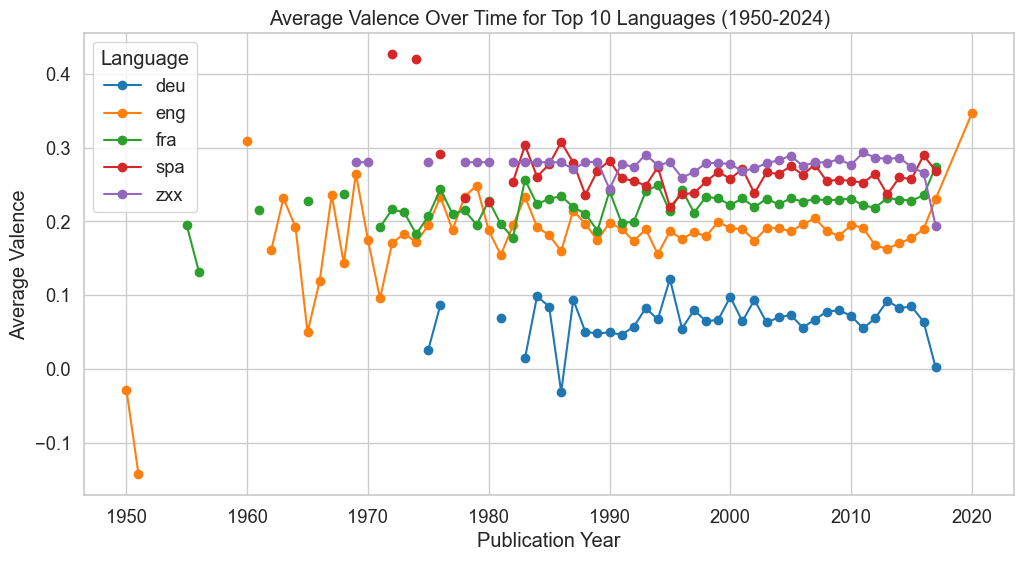

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Assume df is already loaded and has a 'language' and 'publicationYear' column
# Filter by publication year between 1950 and 2024
df = df[(df['publicationYear'] >= 1950) & (df['publicationYear'] <= 2025)]

# Identify top 10 languages by song count
top_languages = df['language'].value_counts().head(5).index.tolist()

# Filter the DataFrame to include only the top 10 languages
df_top = df[df['language'].isin(top_languages)]

# Group by publication year and language, then calculate mean valence, arousal, and dominance
grouped = df_top.groupby(['publicationYear', 'language']).agg({
    'valence_mean': 'mean',
    'arousal_mean': 'mean',
    'dominance_mean': 'mean'
}).reset_index()

# Pivot table for one emotion (e.g., valence)
pivot_valence = grouped.pivot(index='publicationYear', columns='language', values='valence_mean')

# Plot the multi-line chart
pivot_valence.plot(figsize=(12, 6), marker='o')
plt.title("Average Valence Over Time for Top 10 Languages (1950-2024)")
plt.xlabel("Publication Year")
plt.ylabel("Average Valence")
plt.legend(title="Language")
plt.show()

### Identify clusters of songs based on their emotional profiles and see if these clusters align with cultural or language differences.

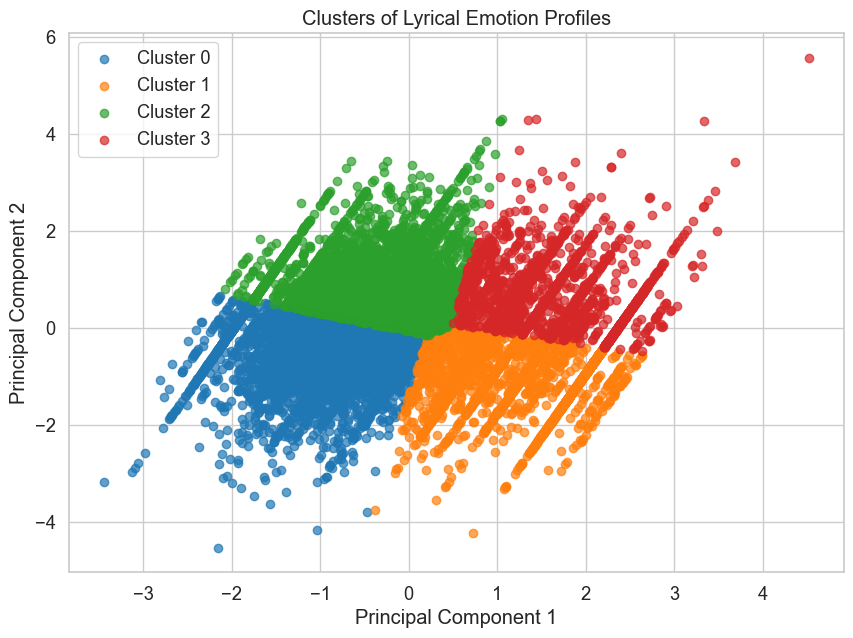

In [45]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select and normalize emotion features (ensure you have a clean subset)
features = df[['valence', 'arousal', 'dominance_lexicon']].dropna()
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled_features)

# Run k-means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(reduced)

# Create a DataFrame for plotting
plot_df = pd.DataFrame(reduced, columns=['PC1', 'PC2'])

plot_df['cluster'] = clusters

# Use .loc with features.index to get the corresponding language values
plot_df['language'] = df.loc[features.index, 'language_detect'].values
plot_df.groupby(['cluster', 'language']).size()
# Plot the clusters
plt.figure(figsize=(10, 7))

for clust in sorted(plot_df['cluster'].unique()):
    subset = plot_df[plot_df['cluster'] == clust]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {clust}', alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Clusters of Lyrical Emotion Profiles")
plt.legend()
plt.show()

In [48]:
# Suppose scaled_features was the standardized valence/arousal/dominance
kmeans_orig = KMeans(n_clusters=4, random_state=42)
clusters_orig = kmeans_orig.fit_predict(scaled_features)

# Cluster centers in scaled space
cluster_centers_scaled = kmeans_orig.cluster_centers_

# Convert cluster centers back to original scale:
unscaled_centers = scaler.inverse_transform(cluster_centers_scaled)
df_centers = pd.DataFrame(unscaled_centers, columns=['valence', 'arousal', 'dominance_lexicon'])
print(df_centers)

    valence   arousal  dominance_lexicon
0  0.334203 -0.931923           0.507529
1  1.083165  1.082297           0.503390
2 -1.083920  0.286986           0.523919
3 -0.874445 -0.006509           0.456699


In [52]:
unscaled_centers = scaler.inverse_transform(cluster_centers_scaled)
unscaled_centers

array([[ 0.3342027 , -0.93192316,  0.50752924],
       [ 1.08316515,  1.08229685,  0.50338988],
       [-1.08391981,  0.28698599,  0.52391885],
       [-0.8744452 , -0.0065086 ,  0.45669916]])

language  dutch  english  french  german  hausa  hawaiian  hungarian  \
cluster                                                                
0             1     5251       3       4      0         1          1   
1             0     2968       0       0      1         0          0   
2             0     4970       1       0      0         0          0   
3             0     2168       0       1      0         0          0   

language  icelandic  italian  latin  polish  portuguese  slovene  somali  \
cluster                                                                    
0                 0        1      0       1           0        1       1   
1                 0        0      0       0           1        0       0   
2                 1        0      1       0           2        0       0   
3                 0        2      1       0           0        0       0   

language  spanish  
cluster            
0               0  
1               2  
2               0  
3         

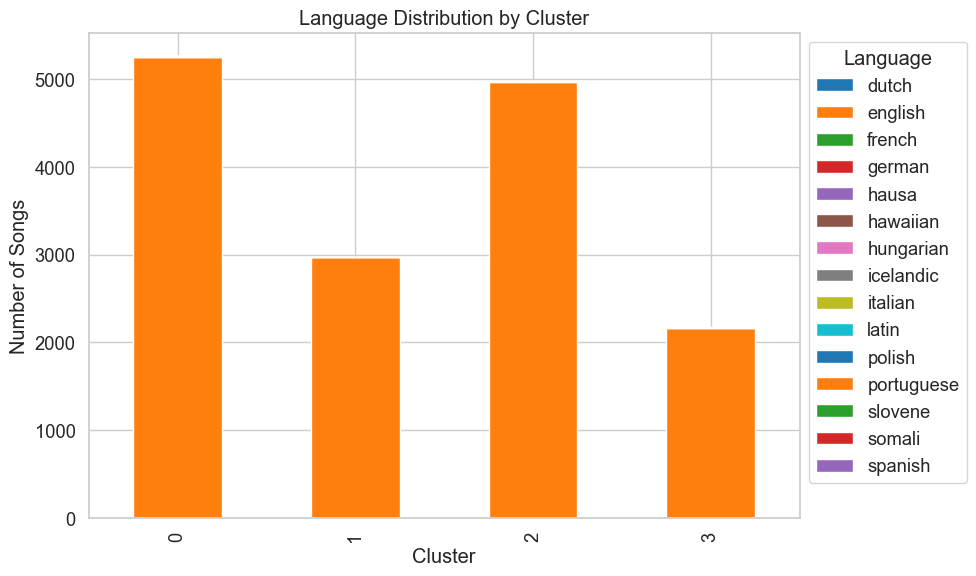

In [54]:
import pandas as pd

# Assuming your final cluster assignments are in df['cluster']
# and your language is in df['language'] (or df['language_detect']).
# Example: df['cluster'] = clusters_orig (from your K-means on scaled features)

# Group by cluster and language
language_cluster_dist = plot_df.groupby(['cluster', 'language']).size().unstack(fill_value=0)

# Print the table
print(language_cluster_dist)

# If you'd like a percentage distribution within each cluster:
language_cluster_percent = language_cluster_dist.apply(lambda x: x / x.sum() * 100, axis=1)
print(language_cluster_percent)

# You can also plot it, for example, as a stacked bar chart:
language_cluster_dist.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Language Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Songs")
plt.legend(title="Language", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

In [56]:
import re
from collections import Counter

# Ensure df has a 'lyrics' column and a 'cluster' column
# Example: df['cluster'] = clusters_orig

def get_top_words(lyrics_series, top_n=20):
    """
    Given a Pandas Series of lyrics (strings), return the top N most common words.
    """
    all_lyrics = " ".join(lyrics_series.dropna().astype(str))
    tokens = re.findall(r'\b\w+\b', all_lyrics.lower())
    counter = Counter(tokens)
    return counter.most_common(top_n)

# Example usage: print top words for each cluster
unique_clusters = df['cluster'].unique()
for c in unique_clusters:
    cluster_lyrics = df.loc[df['cluster'] == c, 'lyrics']
    top_words = get_top_words(cluster_lyrics, top_n=20)
    print(f"\nCluster {c} — Top 20 Words:")
    for word, count in top_words:
        print(f"{word}: {count}")


Cluster nan — Top 20 Words:

Cluster 0.0 — Top 20 Words:
br: 134954
apos: 43380
i: 38118
you: 31530
the: 28598
to: 18138
and: 17636
a: 13509
it: 13501
me: 12015
s: 10839
my: 10598
t: 10178
in: 9726
of: 7978
that: 7927
your: 7715
on: 6819
be: 6324
we: 6307

Cluster 3.0 — Top 20 Words:
br: 163517
apos: 51585
i: 46006
you: 35097
the: 34371
and: 22051
to: 20624
a: 16768
me: 15387
it: 15047
in: 12145
s: 12113
t: 12020
my: 11836
of: 9988
your: 8820
that: 8618
m: 7982
on: 7935
all: 7353

Cluster 1.0 — Top 20 Words:
br: 225333
apos: 81000
i: 65592
you: 55012
the: 45541
and: 28831
to: 27606
it: 25367
a: 24278
me: 21414
s: 19783
t: 18036
my: 16611
in: 15408
that: 13109
we: 12411
your: 12391
of: 11847
on: 11816
m: 10966

Cluster 2.0 — Top 20 Words:
br: 156133
apos: 48881
i: 44959
you: 35878
the: 33543
to: 20658
and: 20097
a: 15274
it: 14936
me: 13770
t: 12243
s: 12166
my: 11866
in: 11313
of: 10940
that: 9082
your: 8649
is: 7130
all: 7102
m: 6843


In [57]:
from sklearn.cluster import KMeans
import numpy as np

scaled_features = scaler.fit_transform(df[['valence', 'arousal', 'dominance_lexicon']].dropna())

for k in [3, 5, 6]:
    kmeans_alt = KMeans(n_clusters=k, random_state=42)
    clusters_alt = kmeans_alt.fit_predict(scaled_features)
    
    # Count how many samples in each cluster
    unique, counts = np.unique(clusters_alt, return_counts=True)
    print(f"\n--- K = {k} ---")
    for cluster_id, count in zip(unique, counts):
        print(f"Cluster {cluster_id}: {count} songs")
    
    # If desired, check silhouette score or inertia for an objective measure
    print(f"Inertia (K={k}): {kmeans_alt.inertia_}")


--- K = 3 ---
Cluster 0: 4566 songs
Cluster 1: 4771 songs
Cluster 2: 6047 songs
Inertia (K=3): 24462.209559069546

--- K = 5 ---
Cluster 0: 2421 songs
Cluster 1: 4373 songs
Cluster 2: 1595 songs
Cluster 3: 4209 songs
Cluster 4: 2786 songs
Inertia (K=5): 17478.350409963197

--- K = 6 ---
Cluster 0: 2677 songs
Cluster 1: 2197 songs
Cluster 2: 1473 songs
Cluster 3: 3309 songs
Cluster 4: 2920 songs
Cluster 5: 2808 songs
Inertia (K=6): 14714.94169505107


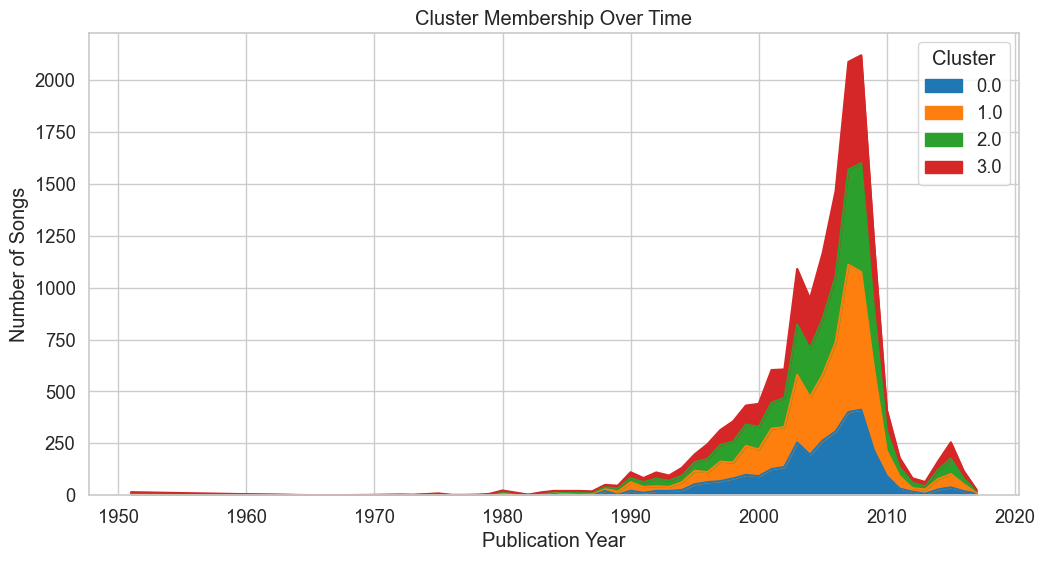

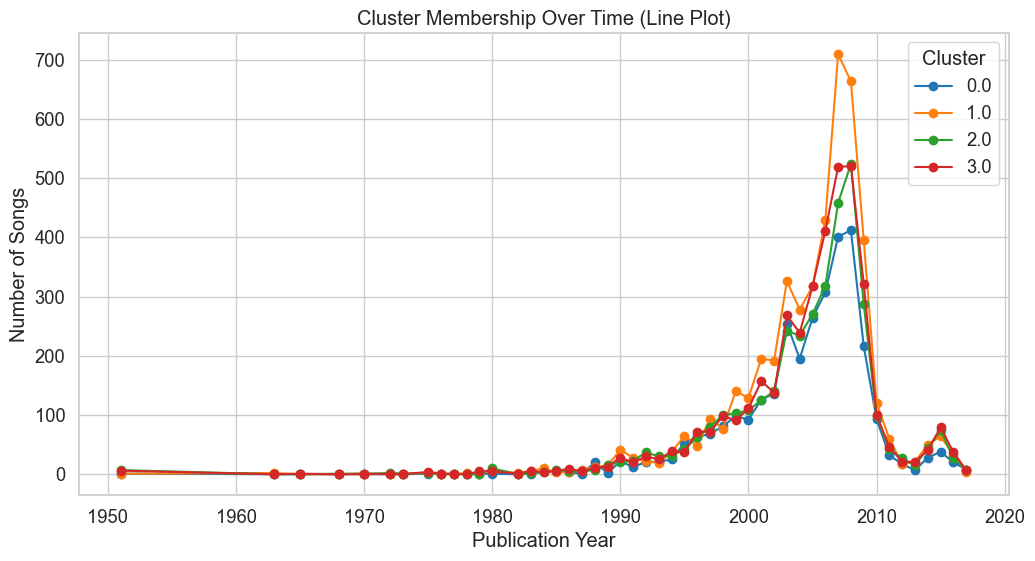

In [58]:
import matplotlib.pyplot as plt

# Ensure df has 'cluster' and 'publicationYear' columns
# Convert to numeric if needed: df['publicationYear'] = pd.to_numeric(df['publicationYear'], errors='coerce')

# Group by cluster and year
cluster_year_counts = df.groupby(['publicationYear', 'cluster']).size().unstack(fill_value=0)

# Plot as a stacked area chart
cluster_year_counts.plot(kind='area', figsize=(12,6))
plt.title("Cluster Membership Over Time")
plt.xlabel("Publication Year")
plt.ylabel("Number of Songs")
plt.legend(title="Cluster")
plt.show()

# Alternatively, if you prefer line charts for each cluster:
cluster_year_counts.plot(figsize=(12,6), marker='o')
plt.title("Cluster Membership Over Time (Line Plot)")
plt.xlabel("Publication Year")
plt.ylabel("Number of Songs")
plt.legend(title="Cluster")
plt.show()

In [55]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# -----------------------------
# 1. Assign Clusters to df
# -----------------------------
# Select the rows with complete emotion features
features = df[['valence', 'arousal', 'dominance_lexicon']].dropna()

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Optional: If you want to visualize in 2D using PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled_features)

# Run KMeans clustering (here using k=4, adjust if needed)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_features)

# Add the cluster assignments back to the original DataFrame for those rows that had complete features
df.loc[features.index, 'cluster'] = clusters

# -----------------------------
# 2. Distribution of Languages per Cluster
# -----------------------------
# Group by 'cluster' and 'language_detect' (or 'language') and count songs
language_cluster_dist = df.groupby(['cluster', 'language']).size().unstack(fill_value=0)
print(language_cluster_dist)

# Optional: Plot a stacked bar chart for distribution
language_cluster_dist.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Language Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Songs")
plt.legend(title="Language", bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Compare Clusters by Lyrics (Top Words)
# -----------------------------
def get_top_words(lyrics_series, top_n=20):
    """
    Given a Pandas Series of lyrics (strings), return the top N most common words.
    """
    all_lyrics = " ".join(lyrics_series.dropna().astype(str))
    tokens = re.findall(r'\b\w+\b', all_lyrics.lower())
    counter = Counter(tokens)
    return counter.most_common(top_n)

# Print top words for each cluster (ensure your df has a 'lyrics' column)
unique_clusters = df['cluster'].dropna().unique()
for c in unique_clusters:
    cluster_lyrics = df.loc[df['cluster'] == c, 'lyrics']
    top_words = get_top_words(cluster_lyrics, top_n=20)
    print(f"\nCluster {int(c)} — Top 20 Words:")
    for word, count in top_words:
        print(f"{word}: {count}")

# -----------------------------
# 4. Try Multiple K Values (3, 5, 6)
# -----------------------------
for k in [3, 5, 6]:
    kmeans_alt = KMeans(n_clusters=k, random_state=42)
    clusters_alt = kmeans_alt.fit_predict(scaled_features)
    
    # Count songs per cluster
    unique, counts = np.unique(clusters_alt, return_counts=True)
    print(f"\n--- K = {k} ---")
    for cluster_id, count in zip(unique, counts):
        print(f"Cluster {cluster_id}: {count} songs")
    
    print(f"Inertia (K={k}): {kmeans_alt.inertia_}")

# -----------------------------
# 5. Analyze Cluster Membership Over Time
# -----------------------------
# Ensure 'publicationYear' column exists and is numeric
# (Adjust column name if necessary; here we assume df has 'publicationYear')
cluster_year_counts = df.groupby(['publicationYear', 'cluster']).size().unstack(fill_value=0)

# Plot as a stacked area chart
cluster_year_counts.plot(kind='area', figsize=(12,6))
plt.title("Cluster Membership Over Time")
plt.xlabel("Publication Year")
plt.ylabel("Number of Songs")
plt.legend(title="Cluster")
plt.show()

# Alternatively, a line plot
cluster_year_counts.plot(figsize=(12,6), marker='o')
plt.title("Cluster Membership Over Time (Line Plot)")
plt.xlabel("Publication Year")
plt.ylabel("Number of Songs")
plt.legend(title="Cluster")
plt.show()

KeyError: 'language_detect'

### 3. Multivariate Regression and Statistical Modeling

Objective:
Model the influence of cultural/language factors on lyrical emotions while controlling for other variables (e.g., classic status, explicit lyrics).


In [50]:
import pandas as pd
import statsmodels.api as sm

# Preprocess data: convert categorical variables into dummies
df = pd.get_dummies(df, columns=['language_detect', 'isClassic', 'explicitLyrics'], drop_first=True)

# Define dependent variable (e.g., valence) and independent variables (include control variables)
X = df.drop(columns=['valence', 'publicationDate', 'publicationDateAlbum', 'lyrics'])
y = df['valence']

# Add constant for intercept
X = sm.add_constant(X)

# Fit the regression model
model = sm.OLS(y, X, missing='drop').fit()

# Print the summary
print(model.summary())

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

4. Topic Modeling & Thematic Analysis

Objective:
Extract topics from lyrics using NLP techniques to see if certain themes correspond with emotional expression across different languages.


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('updated_dataset.csv')

# Sample: Consider only songs with available lyrics and filter by language if needed
lyrics = df['lyrics'].dropna()

# Vectorize the lyrics
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
dtm = vectorizer.fit_transform(lyrics)

# Run LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

# Display top words for each topic
words = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx+1}:")
    print([words[i] for i in topic.argsort()[-10:]])
    print("")

# Further analysis: Map each song to a topic distribution and compare with emotion scores

5. Deep Learning for Contextual Emotion Analysis

Objective:
Use transformer-based models (like BERT) to extract contextual embeddings from lyrics, then compare these embeddings across cultures to understand nuanced emotional expression.


In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Load CSV with lyrics
df = pd.read_csv('updated_dataset.csv')
lyrics = df['lyrics'].dropna().tolist()

# Load a multilingual BERT model and tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-multilingual-cased')
model = AutoModel.from_pretrained('bert-base-multilingual-cased')

# Function to extract the CLS embedding for a given lyric
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :].detach().numpy().flatten()

# Compute embeddings (this might take time, consider sampling for a quick demo)
embeddings = np.array([get_embedding(text) for text in lyrics[:100]])

# Reduce dimensions with t-SNE
tsne = TSNE(n_components=2, random_state=42)
reduced_embeddings = tsne.fit_transform(embeddings)

# Plot the embeddings
plt.figure(figsize=(10, 7))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], alpha=0.7)
plt.title("t-SNE Visualization of Lyrical Emotion Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()